### Imports

In [113]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    repo_dir = "/content/keyboard_sound"  # fixed absolute path

    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}

    %cd {repo_dir}

    !pip install -r requirements_colab.txt

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_249332/1340087408.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [ ]:
data_path= "Data/segmented/alphanum-400"
noise_path="model/Noises"
best_model_path = f"model/CNN-Best{data_path}.pkl"
model_path = f"model/CNN-Final{data_path}.pkl"

### Noise Library Loader & Analyzer

In [116]:
class NoiseLibrary:
    """
    Load and analyze all noise samples for augmentation.
    Stores metadata about each noise: length, RMS level, etc.
    """
    def __init__(self, noise_dir=noise_path):
        self.noise_dir = noise_dir
        self.noises = {
            'city': [],
            'classroom': [],
            'office': [],
            'common': []
        }
        self.noise_metadata = []
        self.load_all_noises()

    def load_all_noises(self):
        """Load all noise files and compute their metadata"""
        print("Loading noise library...")

        # Define category mapping
        categories = {
            'city': 'city',
            'classroom': 'classroom',
            'office': 'office',
            'Common Noises': 'common'
        }

        for category_folder, category_key in categories.items():
            category_path = os.path.join(self.noise_dir, category_folder)
            if not os.path.exists(category_path):
                print(f"Warning: {category_path} not found")
                continue

            for filename in os.listdir(category_path):
                if filename.endswith(('.wav', '.mp3', '.flac', '.ogg')):
                    file_path = os.path.join(category_path, filename)
                    try:
                        waveform, sr = torchaudio.load(file_path)

                        # Convert to mono if stereo
                        if waveform.shape[0] > 1:
                            waveform = torch.mean(waveform, dim=0, keepdim=True)

                        # Resample to 16kHz if needed (standard for keystroke audio)
                        if sr != 44100:
                            resampler = torchaudio.transforms.Resample(sr, 44100)
                            waveform = resampler(waveform)

                        # Calculate RMS (Root Mean Square) for noise level
                        rms = torch.sqrt(torch.mean(waveform ** 2)).item()

                        noise_info = {
                            'category': category_key,
                            'waveform': waveform,
                            'length': waveform.shape[1],
                            'rms': rms,
                            'filename': filename
                        }

                        self.noises[category_key].append(noise_info)
                        self.noise_metadata.append(noise_info)

                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")

        # Print statistics
        total_noises = len(self.noise_metadata)
        print(f"\n✅ Loaded {total_noises} noise samples:")
        for category, noises in self.noises.items():
            if noises:
                avg_len = np.mean([n['length'] for n in noises])
                avg_rms = np.mean([n['rms'] for n in noises])
                print(f"  - {category}: {len(noises)} samples | Avg length: {avg_len/16000:.2f}s | Avg RMS: {avg_rms:.4f}")

    def get_random_noise(self, category=None):
        """Get a random noise sample, optionally from a specific category"""
        if category and self.noises[category]:
            return random.choice(self.noises[category])
        elif self.noise_metadata:
            return random.choice(self.noise_metadata)
        return None

    def get_noise_segment(self, target_length, category=None):
        """Get a noise segment of specified length"""
        noise_info = self.get_random_noise(category)
        if noise_info is None:
            return None

        waveform = noise_info['waveform']
        noise_length = waveform.shape[1]

        if noise_length >= target_length:
            # Random crop
            start = random.randint(0, noise_length - target_length)
            return waveform[:, start:start + target_length]
        else:
            # Loop the noise to match target length
            repeats = (target_length // noise_length) + 1
            waveform = waveform.repeat(1, repeats)
            return waveform[:, :target_length]

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary()
print("✅ Noise Library Ready!\n")

Initializing Noise Library...
Loading noise library...


KeyboardInterrupt: 

### SNR-Based Noise Addition Functions

In [ ]:
def calculate_rms(waveform):
    """Calculate Root Mean Square (RMS) of waveform"""
    return torch.sqrt(torch.mean(waveform ** 2))

def add_noise_snr(signal, noise, target_snr_db):
    """
    Add noise to signal at a specific SNR (Signal-to-Noise Ratio) level.

    Args:
        signal: Clean audio signal (torch.Tensor)
        noise: Noise audio (torch.Tensor)
        target_snr_db: Target SNR in decibels (5-20 dB recommended)
                      5 dB = very noisy, 10 dB = realistic, 20 dB = light noise

    Returns:
        Noisy signal with specified SNR
    """
    # Calculate RMS of signal and noise
    signal_rms = calculate_rms(signal)
    noise_rms = calculate_rms(noise)

    # Calculate required noise scaling factor
    # SNR = 20 * log10(signal_rms / noise_rms)
    # noise_rms_target = signal_rms / (10 ^ (SNR/20))
    snr_linear = 10 ** (target_snr_db / 20.0)
    target_noise_rms = signal_rms / snr_linear

    # Scale noise to achieve target SNR
    scaling_factor = target_noise_rms / (noise_rms + 1e-10)
    scaled_noise = noise * scaling_factor

    # Add noise to signal
    noisy_signal = signal + scaled_noise

    return noisy_signal

def add_white_noise_snr(signal, target_snr_db):
    """
    Add white (uniform) noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with white noise
    """
    # Generate white noise with same shape as signal
    noise = torch.randn_like(signal)
    return add_noise_snr(signal, noise, target_snr_db)

def add_gaussian_noise_snr(signal, target_snr_db):
    """
    Add Gaussian noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with Gaussian noise
    """
    # Generate Gaussian noise
    noise = torch.normal(mean=0, std=0.1, size=signal.shape)
    return add_noise_snr(signal, noise, target_snr_db)

def reduce_volume_db(signal, db_reduction):
    """
    Reduce signal volume by specified dB (simulates microphone placed further away)

    Args:
        signal: Audio signal
        db_reduction: dB to reduce (positive value, e.g., 6 dB, 10 dB, 15 dB)

    Returns:
        Quieter signal
    """
    # Convert dB to linear scale
    # dB = 20 * log10(amplitude_ratio)
    amplitude_ratio = 10 ** (-db_reduction / 20.0)
    return signal * amplitude_ratio

### Hybrid Noise Augmentation Pipeline

In [ ]:
class AggressiveMultiVariationAugmentation:
    """
    AGGRESSIVE multi-variation augmentation for training robustness.

    Applies MANY VARIATIONS with both small and large noise:
    - Real ambient noise (all 4 categories)
    - White noise
    - Gaussian noise
    - Mixed combinations (real+white, real+gaussian)
    - Wide SNR range: 5-30 dB (from noisy to nearly clean)
    - Volume variations
    - Multiple augmentations per sample

    NO CLEAN SAMPLES - Always augment to force model robustness!
    """
    def __init__(self, noise_library,
                 snr_range=(5, 30),           # Min 5dB to avoid signal cancellation
                 volume_reduction_prob=0.4,   # 40% chance
                 volume_reduction_range=(2, 15),  # 2-15 dB reduction
                 multi_aug_prob=0.3):         # 30% chance of multiple augmentations
        self.noise_library = noise_library
        self.snr_range = snr_range
        self.volume_reduction_prob = volume_reduction_prob
        self.volume_reduction_range = volume_reduction_range
        self.multi_aug_prob = multi_aug_prob

        self.strategies = [
            'real_city',
            'real_office',
            'real_classroom',
            'real_common',
            'white',
            'gaussian',
            'mixed_real_white',
            'mixed_real_gaussian',
            'real_random',
        ]

        print(f"🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:")
        print(f"  ├─ Strategies: {len(self.strategies)} different noise types")
        print(f"  ├─ SNR range: {snr_range[0]}-{snr_range[1]} dB")
        print(f"  ├─ Volume reduction: {volume_reduction_prob*100:.0f}% chance")
        print(f"  ├─ Volume reduction range: {volume_reduction_range[0]}-{volume_reduction_range[1]} dB")
        print(f"  ├─ Multi-augmentation: {multi_aug_prob*100:.0f}% chance")
        print(f"  └─ Clean samples: 0% (ALWAYS AUGMENTED!)")

    def apply_augmentation(self, signal, strategy, snr):
        """Apply a single augmentation strategy"""
        signal_length = signal.shape[1] if signal.dim() > 1 else signal.shape[0]

        if strategy == 'real_city':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'city')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_office':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'office')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_classroom':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'classroom')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_common':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'common')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_random':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'white':
            signal = add_white_noise_snr(signal, snr)

        elif strategy == 'gaussian':
            signal = add_gaussian_noise_snr(signal, snr)

        elif strategy == 'mixed_real_white':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_white_noise_snr(signal, snr + 5)

        elif strategy == 'mixed_real_gaussian':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_gaussian_noise_snr(signal, snr + 5)

        return signal

    def __call__(self, signal):
        signal = signal.clone()

        target_snr = random.uniform(self.snr_range[0], self.snr_range[1])
        strategy = random.choice(self.strategies)
        signal = self.apply_augmentation(signal, strategy, target_snr)

        if random.random() < self.multi_aug_prob:
            second_snr = random.uniform(max(target_snr, 10), 30)
            second_strategy = random.choice(['white', 'gaussian'])
            signal = self.apply_augmentation(signal, second_strategy, second_snr)

        if random.random() < self.volume_reduction_prob:
            db_reduction = random.uniform(
                self.volume_reduction_range[0],
                self.volume_reduction_range[1]
            )
            signal = reduce_volume_db(signal, db_reduction)

        return signal

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(5, 30),              # Min 5dB prevents signal cancellation → NaN
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.3
)
print("="*70 + "\n")



🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING
🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:
  ├─ Strategies: 9 different noise types
  ├─ SNR range: 5-30 dB
  ├─ Volume reduction: 40% chance
  ├─ Volume reduction range: 2-15 dB
  ├─ Multi-augmentation: 30% chance
  └─ Clean samples: 0% (ALWAYS AUGMENTED!)



### Loading data

In [ ]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.label_map = {}  # maps raw label string -> contiguous index
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        # First pass: collect all valid label strings
        raw_labels = set()
        for dirname, _, filenames in os.walk(path):
            label = os.path.basename(dirname)
            if filenames and (('0' <= label <= '9') or ('a' <= label <= 'z')):
                raw_labels.add(label)

        # Build contiguous label map (sorted for consistency)
        for idx, label in enumerate(sorted(raw_labels)):
            self.label_map[label] = idx

        # Second pass: load files
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)

                if label not in self.label_map:
                    continue

                label_index = self.label_map[label]
                label_tensor = torch.tensor(label_index)
                self.labels.add(label_tensor.item())

                waveform, sample_rate = torchaudio.load(file_path)

                # ONLY do shape checking if transform exists
                if self.transform is not None:
                    waveform_transformed = self.transform(waveform)
                    if waveform_transformed.shape[2] != 64:
                        print("Wrong shape:", waveform_transformed.shape)
                        continue

                self.n_samples += 1
                self.dataset.append((waveform, label_tensor))  # ← Store RAW audio

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        return waveform, label

    def num_classes(self):
        return len(self.labels)


In [ ]:
sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset(data_path, transforms)
print("number of classes:", dataset.num_classes())


number of classes: 36


In [ ]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices,
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 479, Validation set size: 138, Test set size: 68


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [ ]:
class TrainingDataset(Dataset):
    def __init__(self, base_dataset, transformations):
        super(TrainingDataset, self).__init__()
        self.base = base_dataset
        self.transformations = transformations

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        waveform, label = self.base[idx]
        return self.transformations(waveform), label

In [ ]:
class TimeShifting:
    """Time shifting augmentation with increased shift range for better robustness"""
    def __init__(self, shift_ratio=0.5):
        """
        Args:
            shift_ratio: Ratio of audio length to use as max shift (default 0.5 = 50%)
                        Increased from 0.3 to 0.5 for better temporal variation
        """
        self.shift_ratio = shift_ratio

    def __call__(self, samples):
        if isinstance(samples, torch.Tensor):
            samples = samples.numpy()

        # Increased shift range from 30% to 50% for better augmentation
        shift = int(samples.shape[1] * self.shift_ratio)
        random_shift = random.randint(0, shift)

        data_roll = np.zeros_like(samples)
        for ch in range(samples.shape[0]):
            data_roll[ch] = np.roll(samples[ch], random_shift)

        return torch.tensor(data_roll)

In [ ]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.5),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor
    # HEAVY spectrogram masking for additional robustness
    # FrequencyMasking(10),            # Increased from 7 to 10
    # TimeMasking(10),                 # Increased from 7 to 10
    # FrequencyMasking(10),            # Second pass
    # TimeMasking(10),                 # Second pass
    # FrequencyMasking(5),             # Third pass (lighter)
    # TimeMasking(5),                  # Third pass (lighter)
])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")



✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 479 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 479 samples
  ├─ Validation (no augmentation): 138 samples
  └─ Test (no augmentation): 68 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [ ]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 25
   Waveform shape: torch.Size([1, 18963])
   Sample rate: 44100 Hz
   Duration: 0.430 seconds
   RMS: 0.002871

1️⃣  ORIGINAL CLEAN AUDIO


In [ ]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 0.001439


   🔉 -12 dB reduction - RMS: 0.000721


In [ ]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 0.003012


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003279


In [ ]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 0.003013


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003291


In [ ]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
real_noise_10db = add_noise_snr(
    test_waveform,
    noise_library.get_noise_segment(test_waveform.shape[1]),
    target_snr_db=10
)
real_noise_5db = add_noise_snr(
    test_waveform,
    noise_library.get_noise_segment(test_waveform.shape[1]),
    target_snr_db=5
)

# Convert to numpy
real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

# Save
real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
sf.write(real_10db_path, real_10db_audio, sample_rate)
sf.write(real_5db_path, real_5db_audio, sample_rate)

print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
display(Audio(real_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 0.003004


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003306


### Visualization

torch.Size([64, 64])


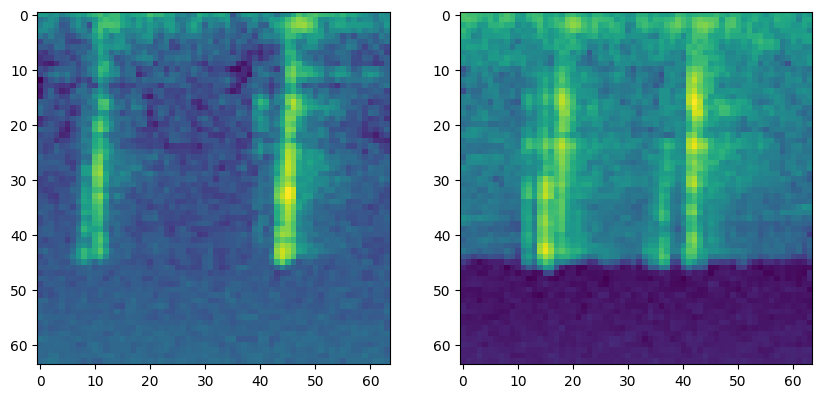

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[3][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()

        self.conv1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.3)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout2d(0.3)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        x = self.global_pool(x)
        x = self.fc(x)

        return x


In [ ]:
model = CNN(num_classes=dataset.num_classes())

In [ ]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
def get_device():
    if torch.cuda.is_available():
        try:
            torch.zeros(1).cuda()
            return 'cuda'
        except Exception as e:
            print(f"⚠️  CUDA available but unusable ({e}), falling back to CPU")
    return 'cpu'

device = get_device()

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))


Number of parameters: 4,856,932
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 36]                   --
├─ConvBlock: 1-1                         [1, 64, 64, 64]           --
│    └─Sequential: 2-1                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           640
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─Dropout2d: 1-3                         [1, 64, 32, 32]           --
├─ConvBlock: 1-4                         [1, 128, 32, 32]          --
│    └─Sequential: 2-2                   [1, 128, 32, 32]          --
│    │  

### Training setup

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

In [ ]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
max_epochs = 1200  # Maximum epochs (safety limit)

# Early Stopping Parameters
early_stopping_patience = 50  # Stop if no improvement for 50 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [ ]:
def plot_results(train_losses, train_accuracies, val_losses, val_accuracies):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")
    plt.subplot(1,2,2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    plt.legend(["Training accuracy", "Validation accuracy"], loc="best")
    plt.show()

In [ ]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=50, min_delta=0.001, mode='min'):
        """
        Args:
            patience: Number of epochs to wait after last improvement
            min_delta: Minimum change in monitored metric to qualify as improvement
            mode: 'min' for loss (lower is better), 'max' for accuracy (higher is better)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.improved = False
        
    def __call__(self, current_score):
        """Check if training should stop"""
        self.improved = False
        
        if self.best_score is None:
            self.best_score = current_score
            self.improved = True
        elif self.mode == 'min':
            if current_score < self.best_score - self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        else:  # mode == 'max'
            if current_score > self.best_score + self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

Epoch [1/1200], Train Loss: 4.9370, Train Acc: 0.0376, Val Loss: 17.0440, Val Acc: 0.0290
  ✓ Best model saved with validation accuracy: 0.0290
Epoch [2/1200], Train Loss: 3.9299, Train Acc: 0.0209, Val Loss: 3.7521, Val Acc: 0.0290
Epoch [3/1200], Train Loss: 3.7429, Train Acc: 0.0271, Val Loss: 3.5866, Val Acc: 0.0217
Epoch [4/1200], Train Loss: 3.6710, Train Acc: 0.0230, Val Loss: 3.5886, Val Acc: 0.0217
Epoch [5/1200], Train Loss: 3.6541, Train Acc: 0.0271, Val Loss: 3.5831, Val Acc: 0.0290
Epoch [6/1200], Train Loss: 3.6741, Train Acc: 0.0355, Val Loss: 3.5831, Val Acc: 0.0290
Epoch [7/1200], Train Loss: 3.6435, Train Acc: 0.0334, Val Loss: 3.5900, Val Acc: 0.0290
Epoch [8/1200], Train Loss: 3.6332, Train Acc: 0.0188, Val Loss: 3.5855, Val Acc: 0.0290
Epoch [9/1200], Train Loss: 3.6097, Train Acc: 0.0418, Val Loss: 3.5789, Val Acc: 0.0725
  ✓ Best model saved with validation accuracy: 0.0725
Epoch [10/1200], Train Loss: 3.6121, Train Acc: 0.0355, Val Loss: 3.5880, Val Acc: 0.0072


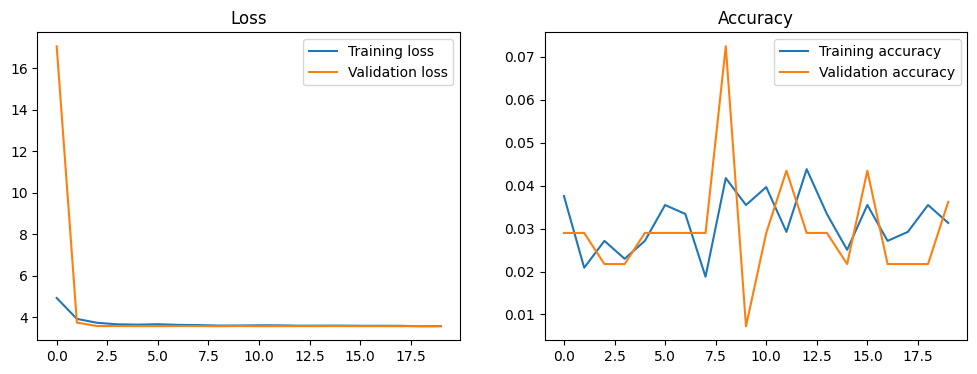

Epoch [21/1200], Train Loss: 3.5842, Train Acc: 0.0271, Val Loss: 3.5810, Val Acc: 0.0290
Epoch [22/1200], Train Loss: 3.6043, Train Acc: 0.0334, Val Loss: 3.5849, Val Acc: 0.0217
Epoch [23/1200], Train Loss: 3.5807, Train Acc: 0.0480, Val Loss: 3.5815, Val Acc: 0.0217
Epoch [24/1200], Train Loss: 3.5890, Train Acc: 0.0355, Val Loss: 3.5832, Val Acc: 0.0290
Epoch [25/1200], Train Loss: 3.5783, Train Acc: 0.0438, Val Loss: 3.5850, Val Acc: 0.0217
Epoch [26/1200], Train Loss: 3.5861, Train Acc: 0.0376, Val Loss: 3.5825, Val Acc: 0.0290
Epoch [27/1200], Train Loss: 3.5818, Train Acc: 0.0334, Val Loss: 3.5774, Val Acc: 0.0217
Epoch [28/1200], Train Loss: 3.5950, Train Acc: 0.0271, Val Loss: 3.5821, Val Acc: 0.0290
Epoch [29/1200], Train Loss: 3.5803, Train Acc: 0.0459, Val Loss: 3.5853, Val Acc: 0.0217
Epoch [30/1200], Train Loss: 3.5719, Train Acc: 0.0397, Val Loss: 3.5702, Val Acc: 0.0507
Epoch [31/1200], Train Loss: 3.5755, Train Acc: 0.0418, Val Loss: 3.5702, Val Acc: 0.0217
Epoch [32/

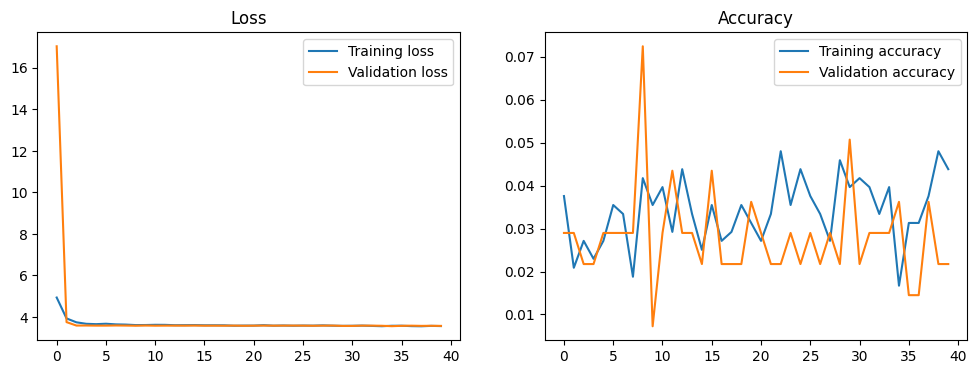

Epoch [41/1200], Train Loss: 3.5840, Train Acc: 0.0230, Val Loss: 3.5769, Val Acc: 0.0507
Epoch [42/1200], Train Loss: 3.5730, Train Acc: 0.0334, Val Loss: 3.5713, Val Acc: 0.0435
Epoch [43/1200], Train Loss: 3.5426, Train Acc: 0.0334, Val Loss: 3.5667, Val Acc: 0.0435
Epoch [44/1200], Train Loss: 3.5508, Train Acc: 0.0376, Val Loss: 3.5488, Val Acc: 0.0797
  ✓ Best model saved with validation accuracy: 0.0797
Epoch [45/1200], Train Loss: 3.5658, Train Acc: 0.0438, Val Loss: 3.5754, Val Acc: 0.0290
Epoch [46/1200], Train Loss: 3.5600, Train Acc: 0.0271, Val Loss: 3.5861, Val Acc: 0.0217
Epoch [47/1200], Train Loss: 3.5752, Train Acc: 0.0334, Val Loss: 3.5789, Val Acc: 0.0217
Epoch [48/1200], Train Loss: 3.5352, Train Acc: 0.0543, Val Loss: 3.5314, Val Acc: 0.0507
Epoch [49/1200], Train Loss: 3.5482, Train Acc: 0.0376, Val Loss: 3.5142, Val Acc: 0.0435
Epoch [50/1200], Train Loss: 3.5493, Train Acc: 0.0397, Val Loss: 3.5649, Val Acc: 0.0362
Epoch [51/1200], Train Loss: 3.5543, Train Acc

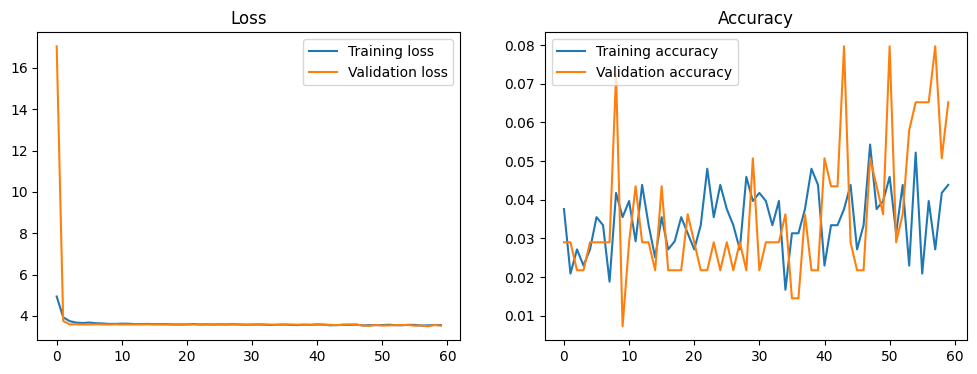

Epoch [61/1200], Train Loss: 3.5420, Train Acc: 0.0438, Val Loss: 3.5474, Val Acc: 0.0507
Epoch [62/1200], Train Loss: 3.5497, Train Acc: 0.0438, Val Loss: 3.5020, Val Acc: 0.0362
Epoch [63/1200], Train Loss: 3.5618, Train Acc: 0.0418, Val Loss: 3.5031, Val Acc: 0.0870
  ✓ Best model saved with validation accuracy: 0.0870
Epoch [64/1200], Train Loss: 3.5285, Train Acc: 0.0418, Val Loss: 3.5550, Val Acc: 0.0435
Epoch [65/1200], Train Loss: 3.5347, Train Acc: 0.0376, Val Loss: 3.5320, Val Acc: 0.0362
Epoch [66/1200], Train Loss: 3.5288, Train Acc: 0.0438, Val Loss: 3.4890, Val Acc: 0.0870
Epoch [67/1200], Train Loss: 3.5497, Train Acc: 0.0334, Val Loss: 3.4414, Val Acc: 0.0435
Epoch [68/1200], Train Loss: 3.5503, Train Acc: 0.0480, Val Loss: 3.4313, Val Acc: 0.0290
Epoch [69/1200], Train Loss: 3.5431, Train Acc: 0.0271, Val Loss: 3.5244, Val Acc: 0.0362
Epoch [70/1200], Train Loss: 3.5401, Train Acc: 0.0334, Val Loss: 3.4597, Val Acc: 0.0580
Epoch [71/1200], Train Loss: 3.5788, Train Acc

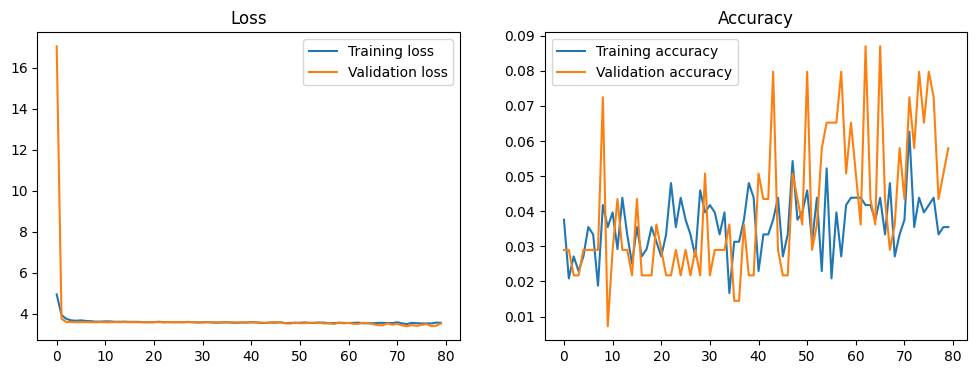

Epoch [81/1200], Train Loss: 3.5143, Train Acc: 0.0397, Val Loss: 3.4145, Val Acc: 0.0580
Epoch [82/1200], Train Loss: 3.5018, Train Acc: 0.0459, Val Loss: 3.4188, Val Acc: 0.0652
Epoch [83/1200], Train Loss: 3.5355, Train Acc: 0.0480, Val Loss: 3.5469, Val Acc: 0.0362
Epoch [84/1200], Train Loss: 3.5712, Train Acc: 0.0355, Val Loss: 3.5534, Val Acc: 0.0580
Epoch [85/1200], Train Loss: 3.5033, Train Acc: 0.0438, Val Loss: 3.5169, Val Acc: 0.0580
Epoch [86/1200], Train Loss: 3.5047, Train Acc: 0.0438, Val Loss: 3.5038, Val Acc: 0.0580
Epoch [87/1200], Train Loss: 3.5199, Train Acc: 0.0543, Val Loss: 3.4807, Val Acc: 0.0725
Epoch [88/1200], Train Loss: 3.5260, Train Acc: 0.0564, Val Loss: 3.4760, Val Acc: 0.0652
Epoch [89/1200], Train Loss: 3.5507, Train Acc: 0.0480, Val Loss: 3.4168, Val Acc: 0.0652
Epoch [90/1200], Train Loss: 3.5070, Train Acc: 0.0355, Val Loss: 3.4055, Val Acc: 0.0652
Epoch [91/1200], Train Loss: 3.5059, Train Acc: 0.0480, Val Loss: 3.3874, Val Acc: 0.0870
Epoch [92/

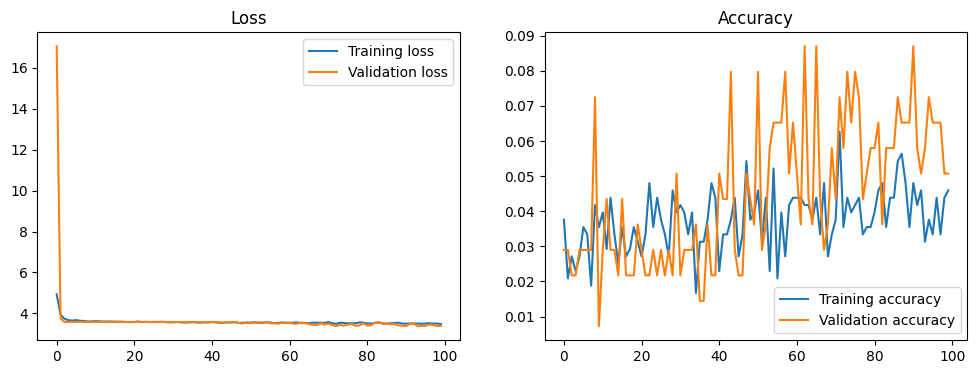

Epoch [101/1200], Train Loss: 3.5000, Train Acc: 0.0501, Val Loss: 3.4046, Val Acc: 0.0507
Epoch [102/1200], Train Loss: 3.5510, Train Acc: 0.0397, Val Loss: 3.4909, Val Acc: 0.0580
Epoch [103/1200], Train Loss: 3.5072, Train Acc: 0.0585, Val Loss: 3.4056, Val Acc: 0.0725
Epoch [104/1200], Train Loss: 3.5236, Train Acc: 0.0480, Val Loss: 3.3732, Val Acc: 0.0797
Epoch [105/1200], Train Loss: 3.5016, Train Acc: 0.0501, Val Loss: 3.3902, Val Acc: 0.0652
Epoch [106/1200], Train Loss: 3.4945, Train Acc: 0.0522, Val Loss: 3.4203, Val Acc: 0.0652
Epoch [107/1200], Train Loss: 3.4987, Train Acc: 0.0501, Val Loss: 3.3739, Val Acc: 0.0797
Epoch [108/1200], Train Loss: 3.5079, Train Acc: 0.0522, Val Loss: 3.3637, Val Acc: 0.0580
Epoch [109/1200], Train Loss: 3.5022, Train Acc: 0.0522, Val Loss: 3.3942, Val Acc: 0.0507
Epoch [110/1200], Train Loss: 3.4619, Train Acc: 0.0564, Val Loss: 3.3864, Val Acc: 0.0507
Epoch [111/1200], Train Loss: 3.4961, Train Acc: 0.0376, Val Loss: 3.4259, Val Acc: 0.0652

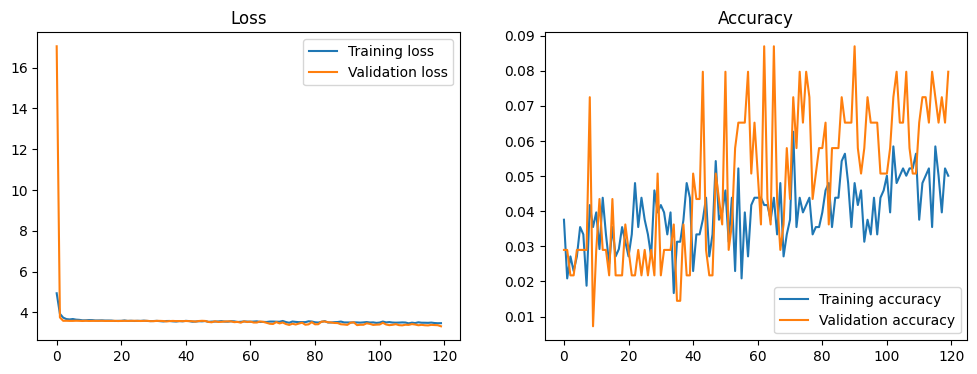

Epoch [121/1200], Train Loss: 3.4578, Train Acc: 0.0397, Val Loss: 3.3211, Val Acc: 0.0652
Epoch [122/1200], Train Loss: 3.5077, Train Acc: 0.0459, Val Loss: 3.3419, Val Acc: 0.0652
Epoch [123/1200], Train Loss: 3.4539, Train Acc: 0.0605, Val Loss: 3.3719, Val Acc: 0.0507
Epoch [124/1200], Train Loss: 3.4947, Train Acc: 0.0438, Val Loss: 3.3254, Val Acc: 0.0580
Epoch [125/1200], Train Loss: 3.4905, Train Acc: 0.0355, Val Loss: 3.4152, Val Acc: 0.0942
  ✓ Best model saved with validation accuracy: 0.0942
Epoch [126/1200], Train Loss: 3.4732, Train Acc: 0.0564, Val Loss: 3.3437, Val Acc: 0.0652
Epoch [127/1200], Train Loss: 3.4488, Train Acc: 0.0543, Val Loss: 3.3611, Val Acc: 0.0870
Epoch [128/1200], Train Loss: 3.4872, Train Acc: 0.0271, Val Loss: 3.3651, Val Acc: 0.0580
Epoch [129/1200], Train Loss: 3.4659, Train Acc: 0.0605, Val Loss: 3.3519, Val Acc: 0.0725
Epoch [130/1200], Train Loss: 3.4732, Train Acc: 0.0585, Val Loss: 3.3620, Val Acc: 0.0797
Epoch [131/1200], Train Loss: 3.4628

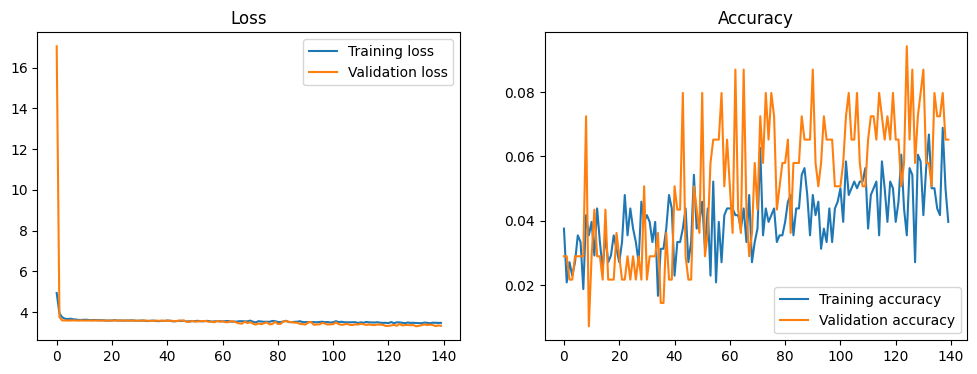

Epoch [141/1200], Train Loss: 3.4404, Train Acc: 0.0605, Val Loss: 3.3058, Val Acc: 0.0652
Epoch [142/1200], Train Loss: 3.4316, Train Acc: 0.0626, Val Loss: 3.3150, Val Acc: 0.0725
Epoch [143/1200], Train Loss: 3.4698, Train Acc: 0.0543, Val Loss: 3.3284, Val Acc: 0.0870
Epoch [144/1200], Train Loss: 3.4633, Train Acc: 0.0522, Val Loss: 3.3161, Val Acc: 0.0652
Epoch [145/1200], Train Loss: 3.4256, Train Acc: 0.0522, Val Loss: 3.2981, Val Acc: 0.0725
Epoch [146/1200], Train Loss: 3.4801, Train Acc: 0.0438, Val Loss: 3.3017, Val Acc: 0.0725
Epoch [147/1200], Train Loss: 3.4211, Train Acc: 0.0438, Val Loss: 3.3007, Val Acc: 0.0652
Epoch [148/1200], Train Loss: 3.4615, Train Acc: 0.0564, Val Loss: 3.3029, Val Acc: 0.0652
Epoch [149/1200], Train Loss: 3.4251, Train Acc: 0.0543, Val Loss: 3.3194, Val Acc: 0.0580
Epoch [150/1200], Train Loss: 3.4144, Train Acc: 0.0689, Val Loss: 3.2647, Val Acc: 0.0580
Epoch [151/1200], Train Loss: 3.4327, Train Acc: 0.0480, Val Loss: 3.3088, Val Acc: 0.0580

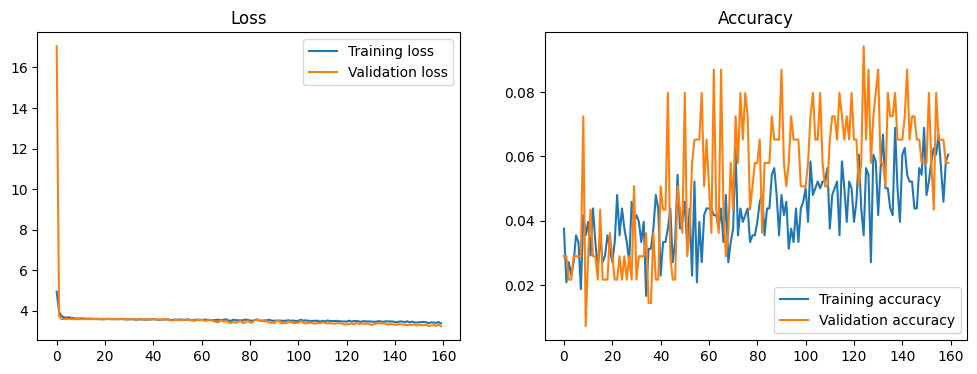

Epoch [161/1200], Train Loss: 3.4304, Train Acc: 0.0626, Val Loss: 3.2674, Val Acc: 0.0797
Epoch [162/1200], Train Loss: 3.3994, Train Acc: 0.0564, Val Loss: 3.2839, Val Acc: 0.0580
Epoch [163/1200], Train Loss: 3.4330, Train Acc: 0.0605, Val Loss: 3.3241, Val Acc: 0.0507
Epoch [164/1200], Train Loss: 3.3969, Train Acc: 0.0522, Val Loss: 3.2357, Val Acc: 0.0652
Epoch [165/1200], Train Loss: 3.4218, Train Acc: 0.0438, Val Loss: 3.3051, Val Acc: 0.0580
Epoch [166/1200], Train Loss: 3.3856, Train Acc: 0.0564, Val Loss: 3.2821, Val Acc: 0.0580
Epoch [167/1200], Train Loss: 3.3750, Train Acc: 0.0668, Val Loss: 3.2479, Val Acc: 0.0725
Epoch [168/1200], Train Loss: 3.3687, Train Acc: 0.0689, Val Loss: 3.2680, Val Acc: 0.0652
Epoch [169/1200], Train Loss: 3.3657, Train Acc: 0.0835, Val Loss: 3.1788, Val Acc: 0.0725
Epoch [170/1200], Train Loss: 3.3713, Train Acc: 0.0710, Val Loss: 3.2472, Val Acc: 0.0507
Epoch [171/1200], Train Loss: 3.3718, Train Acc: 0.0605, Val Loss: 3.2654, Val Acc: 0.0507

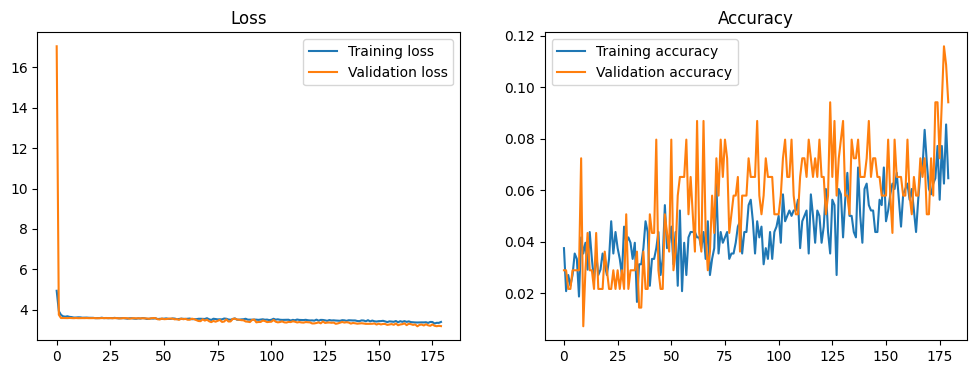

Epoch [181/1200], Train Loss: 3.3788, Train Acc: 0.0397, Val Loss: 3.1668, Val Acc: 0.1014
Epoch [182/1200], Train Loss: 3.3208, Train Acc: 0.0710, Val Loss: 3.1837, Val Acc: 0.0942
Epoch [183/1200], Train Loss: 3.2976, Train Acc: 0.0877, Val Loss: 3.1600, Val Acc: 0.0942
Epoch [184/1200], Train Loss: 3.3881, Train Acc: 0.0710, Val Loss: 3.2084, Val Acc: 0.1159
Epoch [185/1200], Train Loss: 3.3208, Train Acc: 0.0814, Val Loss: 3.1829, Val Acc: 0.1087
Epoch [186/1200], Train Loss: 3.3584, Train Acc: 0.0585, Val Loss: 3.1912, Val Acc: 0.1014
Epoch [187/1200], Train Loss: 3.3124, Train Acc: 0.0438, Val Loss: 3.1802, Val Acc: 0.1087
Epoch [188/1200], Train Loss: 3.3110, Train Acc: 0.0856, Val Loss: 3.1648, Val Acc: 0.1087
Epoch [189/1200], Train Loss: 3.3139, Train Acc: 0.0752, Val Loss: 3.1627, Val Acc: 0.0942
Epoch [190/1200], Train Loss: 3.2885, Train Acc: 0.0710, Val Loss: 3.1795, Val Acc: 0.0942
Epoch [191/1200], Train Loss: 3.3262, Train Acc: 0.0710, Val Loss: 3.1686, Val Acc: 0.1014

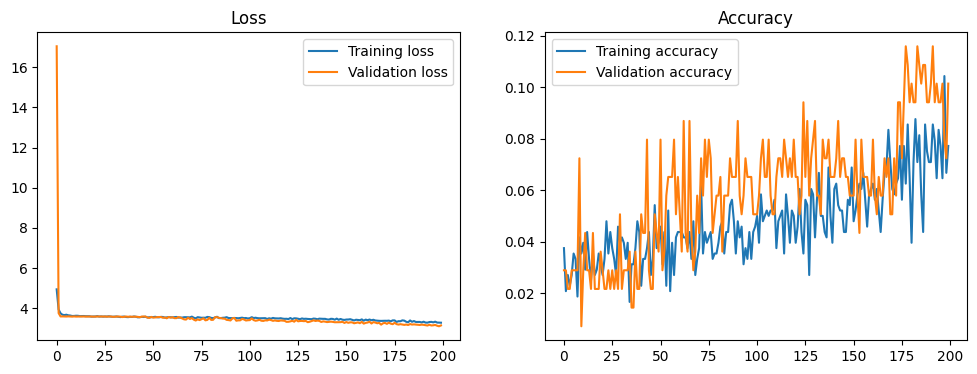

Epoch [201/1200], Train Loss: 3.3272, Train Acc: 0.0647, Val Loss: 3.1668, Val Acc: 0.1087
Epoch [202/1200], Train Loss: 3.2403, Train Acc: 0.0835, Val Loss: 3.1097, Val Acc: 0.0797
Epoch [203/1200], Train Loss: 3.2388, Train Acc: 0.0626, Val Loss: 3.1239, Val Acc: 0.0870
Epoch [204/1200], Train Loss: 3.2815, Train Acc: 0.0668, Val Loss: 3.1233, Val Acc: 0.0870
Epoch [205/1200], Train Loss: 3.2576, Train Acc: 0.0793, Val Loss: 3.1370, Val Acc: 0.0942
Epoch [206/1200], Train Loss: 3.2568, Train Acc: 0.0960, Val Loss: 3.1088, Val Acc: 0.0870
Epoch [207/1200], Train Loss: 3.2357, Train Acc: 0.0939, Val Loss: 3.1194, Val Acc: 0.1159
Epoch [208/1200], Train Loss: 3.2363, Train Acc: 0.0772, Val Loss: 3.1527, Val Acc: 0.1449
  ✓ Best model saved with validation accuracy: 0.1449
Epoch [209/1200], Train Loss: 3.2208, Train Acc: 0.0919, Val Loss: 3.0933, Val Acc: 0.1159
Epoch [210/1200], Train Loss: 3.2542, Train Acc: 0.0772, Val Loss: 3.0878, Val Acc: 0.1087
Epoch [211/1200], Train Loss: 3.2515

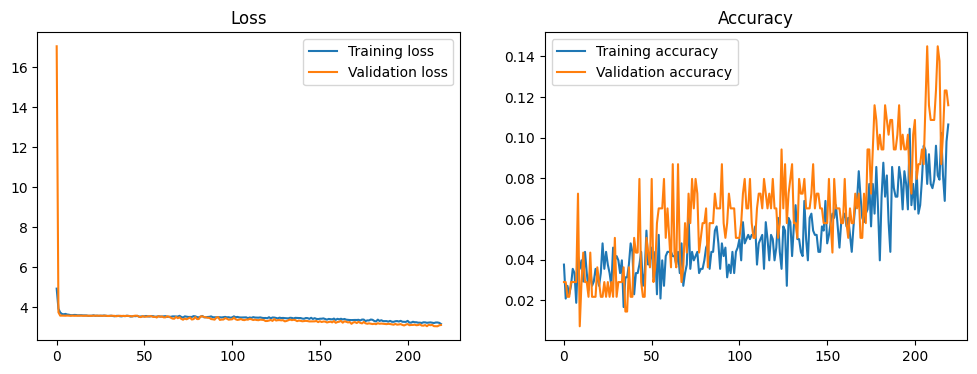

Epoch [221/1200], Train Loss: 3.2288, Train Acc: 0.0710, Val Loss: 3.0699, Val Acc: 0.1232
Epoch [222/1200], Train Loss: 3.2013, Train Acc: 0.0856, Val Loss: 3.0834, Val Acc: 0.1087
Epoch [223/1200], Train Loss: 3.2618, Train Acc: 0.1023, Val Loss: 3.0861, Val Acc: 0.1159
Epoch [224/1200], Train Loss: 3.1704, Train Acc: 0.0919, Val Loss: 3.1371, Val Acc: 0.1304
Epoch [225/1200], Train Loss: 3.2292, Train Acc: 0.0793, Val Loss: 3.1471, Val Acc: 0.1159
Epoch [226/1200], Train Loss: 3.1998, Train Acc: 0.0856, Val Loss: 3.1428, Val Acc: 0.1304
Epoch [227/1200], Train Loss: 3.1986, Train Acc: 0.0919, Val Loss: 3.1189, Val Acc: 0.1232
Epoch [228/1200], Train Loss: 3.1827, Train Acc: 0.0814, Val Loss: 3.0744, Val Acc: 0.1014
Epoch [229/1200], Train Loss: 3.1493, Train Acc: 0.0939, Val Loss: 3.0610, Val Acc: 0.0942
Epoch [230/1200], Train Loss: 3.1423, Train Acc: 0.1023, Val Loss: 3.0554, Val Acc: 0.0942
Epoch [231/1200], Train Loss: 3.1632, Train Acc: 0.0981, Val Loss: 3.0512, Val Acc: 0.1087

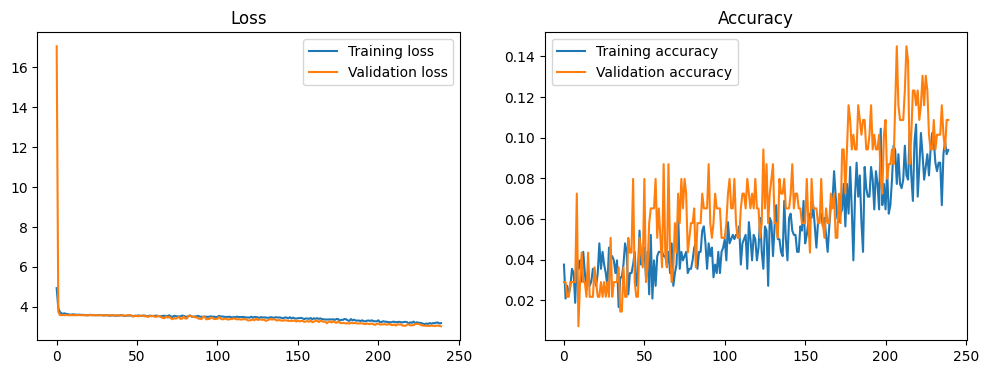

Epoch [241/1200], Train Loss: 3.1518, Train Acc: 0.0981, Val Loss: 3.0631, Val Acc: 0.1087
Epoch [242/1200], Train Loss: 3.1584, Train Acc: 0.0835, Val Loss: 3.0340, Val Acc: 0.1014
Epoch [243/1200], Train Loss: 3.1558, Train Acc: 0.0856, Val Loss: 3.0572, Val Acc: 0.1232
Epoch [244/1200], Train Loss: 3.2256, Train Acc: 0.0856, Val Loss: 3.0565, Val Acc: 0.1087
Epoch [245/1200], Train Loss: 3.1198, Train Acc: 0.1044, Val Loss: 3.0177, Val Acc: 0.1159
Epoch [246/1200], Train Loss: 3.1183, Train Acc: 0.1127, Val Loss: 3.0536, Val Acc: 0.1304
Epoch [247/1200], Train Loss: 3.1450, Train Acc: 0.0877, Val Loss: 3.0443, Val Acc: 0.1377
Epoch [248/1200], Train Loss: 3.1199, Train Acc: 0.0814, Val Loss: 3.0272, Val Acc: 0.1087
Epoch [249/1200], Train Loss: 3.1990, Train Acc: 0.0710, Val Loss: 3.0539, Val Acc: 0.1087
Epoch [250/1200], Train Loss: 3.1601, Train Acc: 0.0898, Val Loss: 3.0310, Val Acc: 0.0942
Epoch [251/1200], Train Loss: 3.1028, Train Acc: 0.0898, Val Loss: 3.0183, Val Acc: 0.0870

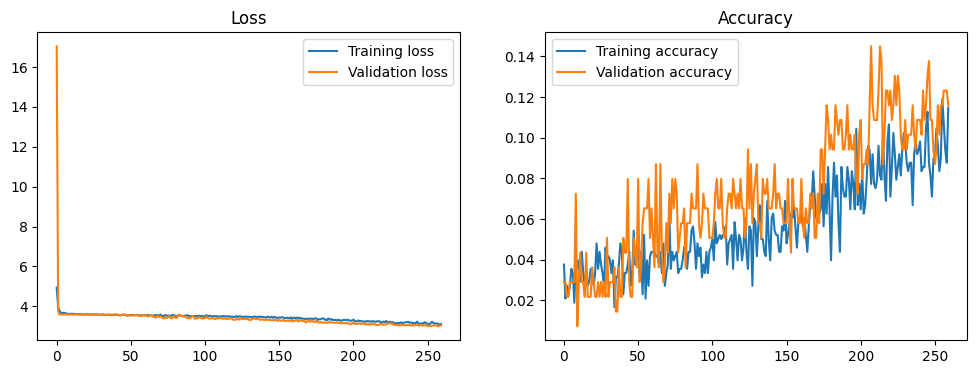

Epoch [261/1200], Train Loss: 3.1169, Train Acc: 0.0939, Val Loss: 2.9889, Val Acc: 0.1232
Epoch [262/1200], Train Loss: 3.1001, Train Acc: 0.0981, Val Loss: 2.9998, Val Acc: 0.1159
Epoch [263/1200], Train Loss: 3.1373, Train Acc: 0.1086, Val Loss: 2.9847, Val Acc: 0.1232
Epoch [264/1200], Train Loss: 3.1019, Train Acc: 0.1002, Val Loss: 2.9889, Val Acc: 0.1159
Epoch [265/1200], Train Loss: 3.1117, Train Acc: 0.1086, Val Loss: 2.9579, Val Acc: 0.1304
Epoch [266/1200], Train Loss: 3.1664, Train Acc: 0.0939, Val Loss: 3.0040, Val Acc: 0.1232
Epoch [267/1200], Train Loss: 3.1077, Train Acc: 0.0960, Val Loss: 3.0188, Val Acc: 0.1377
Epoch [268/1200], Train Loss: 3.1100, Train Acc: 0.1002, Val Loss: 2.9791, Val Acc: 0.1232
Epoch [269/1200], Train Loss: 3.0928, Train Acc: 0.1044, Val Loss: 2.9634, Val Acc: 0.1232
Epoch [270/1200], Train Loss: 3.0973, Train Acc: 0.1065, Val Loss: 2.9764, Val Acc: 0.1232
Epoch [271/1200], Train Loss: 3.0737, Train Acc: 0.1148, Val Loss: 2.9779, Val Acc: 0.1304

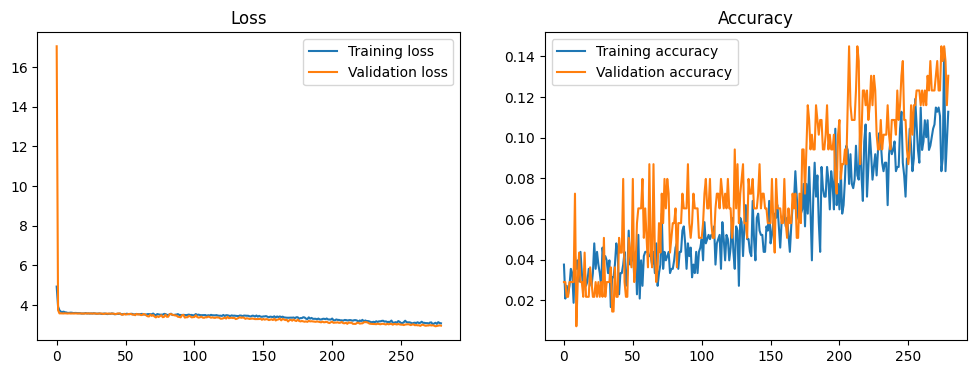

Epoch [281/1200], Train Loss: 3.0992, Train Acc: 0.1065, Val Loss: 2.9729, Val Acc: 0.1304
Epoch [282/1200], Train Loss: 3.1004, Train Acc: 0.1253, Val Loss: 3.0155, Val Acc: 0.1087
Epoch [283/1200], Train Loss: 3.1034, Train Acc: 0.1023, Val Loss: 2.9825, Val Acc: 0.1232
Epoch [284/1200], Train Loss: 3.0839, Train Acc: 0.0960, Val Loss: 2.9813, Val Acc: 0.1232
Epoch [285/1200], Train Loss: 3.0425, Train Acc: 0.1002, Val Loss: 2.9496, Val Acc: 0.1159
Epoch [286/1200], Train Loss: 3.0809, Train Acc: 0.1065, Val Loss: 2.9355, Val Acc: 0.1159
Epoch [287/1200], Train Loss: 3.0425, Train Acc: 0.1127, Val Loss: 2.9850, Val Acc: 0.1159
Epoch [288/1200], Train Loss: 3.0820, Train Acc: 0.0856, Val Loss: 2.9324, Val Acc: 0.1232
Epoch [289/1200], Train Loss: 3.0494, Train Acc: 0.1086, Val Loss: 2.9173, Val Acc: 0.1377
Epoch [290/1200], Train Loss: 3.1109, Train Acc: 0.0772, Val Loss: 2.9556, Val Acc: 0.1159
Epoch [291/1200], Train Loss: 3.0618, Train Acc: 0.1002, Val Loss: 2.9833, Val Acc: 0.1159

KeyboardInterrupt: 

In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(patience=early_stopping_patience, 
                                min_delta=early_stopping_min_delta, 
                                mode='min')  # Monitor validation loss

print(f"🚀 Starting training with early stopping:")
print(f"   • Max epochs: {max_epochs}")
print(f"   • Early stopping patience: {early_stopping_patience} epochs")
print(f"   • Min delta: {early_stopping_min_delta}")
print(f"   • Monitoring: Validation Loss\n")

for epoch in range(max_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()

    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        val_loss = 0

        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)

            loss = cost(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch + 1}/{max_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")
    
    # Early stopping check
    if early_stopping(avg_val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        print(f"   • No improvement in validation loss for {early_stopping.patience} epochs")
        print(f"   • Best validation loss: {early_stopping.best_score:.4f}")
        print(f"   • Best validation accuracy: {best_val_acc:.4f}")
        break

# Final summary
if not early_stopping.early_stop:
    print(f"\n✅ Training completed - reached maximum epochs ({max_epochs})")
else:
    print(f"\n✅ Training completed - early stopping at epoch {epoch + 1}")
    
print(f"   • Total epochs trained: {len(train_losses)}")
print(f"   • Best validation accuracy: {best_val_acc:.4f}")
print(f"   • Final validation accuracy: {val_accuracies[-1]:.4f}")

In [ ]:
save_model(model, model_path)

In [ ]:
# Plot final training results
plot_results(train_losses, train_accuracies, val_losses, val_accuracies)

print(f"\n📊 Training Summary:")
print(f"   • Best validation acc: {max(val_accuracies):.4f}")
print(f"   • Last validation acc: {val_accuracies[-1]:.4f}")
print(f"   • Epochs trained: {len(val_accuracies)}")

---

## 🔧 Fine-Tuning

For fine-tuning a trained model on production/deployment data, use:

**[CNN-FineTuning.ipynb](CNN-FineTuning.ipynb)**

This separate notebook allows you to:
- Load a pre-trained model from this notebook
- Fine-tune on small production datasets  
- Freeze early layers for better performance on small data
- Compare original vs fine-tuned model accuracy

---

### Results

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

In [ ]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

In [ ]:
def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0

    model.eval()

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)

        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels],
        "true_labels": [label_dict[label] for label in original_labels]
    })

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)

    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))

    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [ ]:
cm = predict(test_dataloader)

### Confusion matrix

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters,
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
plt.show()